# Карта пользовательских потоков (User Flow Sankey Diagram)

Проект выполнен на основе датасета "The Puffy "Lost Sleep" Challenge", размещенного на [kaggle](https://www.kaggle.com/competitions/the-puffy-lost-sleepchallenge/data) 

Датасет включает 2 таблицы:
- `events` с действиями пользователей на сайте https://puffy.com компании, реализующей матрасы 
- `tags` c идентификаторами пользователей, заказавших продукцию и меткой о наличии/отсутствии возврата

Задача проекта - построить карту пользовательских потоков (User Flow Sankey Diagram), вернувших товар, чтобы понять, на каком этапе пользователь принимает решение о возврате.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import psycopg2
from sqlalchemy import create_engine, text
from tqdm.auto import tqdm
import plotly.graph_objects as go
import requests

d:\-_SHv_4lM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pd.set_option('display.max_rows', None)

## Подключение к базе

Для удобства работы локально была развернута база данных PostgreSQL, в которую импортированы таблицы из исследуемого датасета. Дальнейшая выгрузка данных будет выполняться с помощью SQL-запросов к этой базе

In [3]:
with open('creds.txt', 'r', encoding='utf-8') as file:
    creds = file.read().splitlines()

# создание соединения с базой и проверка
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'database': creds[0],  
    'user': creds[1],
    'password': creds[2]  
}

engine = create_engine(
    f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

# проверка соединения
with engine.connect() as conn:
    result = conn.execute(text("SELECT current_database(), version();"))
    db_name, version = result.fetchone()
    print(f"Connected to: {db_name}")
    print(f"PostgreSQL version: {version[:20]}...")

# выводим список таблиц в базе и количество строк в каждой
tables_df = pd.read_sql_query("""
    SELECT 
        schemaname,
        relname as table_name,
        n_live_tup as estimated_rows
    FROM pg_stat_user_tables 
    WHERE schemaname = 'public';
""", engine)

print(tables_df)

Connected to: analytics_cjm
PostgreSQL version: PostgreSQL 17.10 on ...
  schemaname table_name  estimated_rows
0     public       tags             401
1     public     events           58119


## Выгрузка и преобразование данных

Выгружаем события для пользователей сделавших возврат

In [4]:
%%time

df_init = pd.read_sql_query("""
    SELECT 
        events.client_id AS client_id
        ,event_name
        ,event_timestamp
        ,event_data
    FROM events
    JOIN tags
    USING(client_id)
    WHERE refunded = 1
""", engine)

CPU times: total: 78.1 ms
Wall time: 318 ms


In [5]:
df_init.sample(5)

,client_id,event_name,event_timestamp,event_data
4906,1741630180-9UYvVrb6rCTd,checkout_started,2025-03-13 00:28:02.765,150983180312
2574,1740949737-CpZuFExcAu_m,page_viewed,2025-03-04 19:41:50.314,/cart
16837,1741024717-M2EWVoNJXw45,clicked,2025-03-03 18:00:53.756,"{""element_identifier"":""label""}"
12330,1742251714-isaY7efAVv0j,clicked,2025-03-17 22:49:30.376,"{""element_identifier"":""main_size_selector""}"
5356,1737698437-nxVsCpCyGfTQ,page_viewed,2025-02-11 02:01:37.740,/products/puffy-lux-mattress


In [6]:
# уникальные события

df_init.event_name.unique()

array(['clicked', 'page_viewed', 'size_changed', 'product_added_to_cart',
       'checkout_completed', 'checkout_started',
       'product_removed_from_cart'], dtype=object)

Принимая во внимание, что Sankey-диаграмма является достаточно сложной визуализацией, для возможности ее восприятия не рекомендуется включать в нее более 50 шагов, даже для аналитических исследований. В связи с этим необходимо выполнить обработку событий, оставив наиболее значимые.

События `product_added_to_cart`, `checkout_started`, `product_removed_from_cart`, `checkout_completed` включим в карту без изменений. Они дают основную информацию о том, что пользователь вошел в воронку покупки продукта. Событие `size_changed` исключим, т.к. оно в контексте решаемой задачи не несет существенной информации.

Понимание остального пути пользователя (вне действий по добавлению продукта в корзину, оплаты) может быть сформировано на базе событий `clicked` и/или `page_viewed`. В рамках данной задачи, посмотрим глобально, какими страницами интересовались пользователи на пути к покупке продукта. То есть будем базироваться на событиях `page_viewed`. Разобьем страницы, которые посещали пользователи на группы в соответствии с их тематикой и ролью. Разбиение будет базироваться на атрибуте `event_data` событий с `event_name == 'page_viewed'`

С учетом вышеизложенного выполним преобразование событий

In [7]:
# исключаем из рассмотрения события кликов и выбора размера
df_init = df_init[~df_init.event_name.isin(['clicked', 'size_changed'])]

# создаем маску для page_viewed
mask_page_viewed = df_init.event_name == 'page_viewed'

# условия замены
conditions = [
    (df_init.event_data == '/'),
    ((df_init.event_data.str.startswith('/pages/puffy-mattress-and-puffy-lux')) | 
     (df_init.event_data.str.startswith('/collections')) |
     (df_init.event_data.str.startswith('/products'))),
    ((df_init.event_data.str.startswith('/pages')) & (df_init.event_data.str.contains('-vs-')) |
     (df_init.event_data == '/pages/puffy-mattress-comparison') |
     (df_init.event_data.isin(['/pages/unboxing-your-puffy-mattress', '/pages/breaking-in-your-new-puffy', 
                        '/pages/puffy-mattress-weight', '/pages/puffy-mattress-made-in-the-usa',
                        '/pages/top-rated-best-mattress-awards', 
                        '/pages/queen-mattresses', '/pages/king-mattresses',
                        '/pages/puffy-donations', '/pages/affiliates-program',
                        '/pages/easy-puffy-mattress-setup', '/pages/split-king-mattresses',
                        '/pages/certipur-us-certified'])) |
     (df_init.event_data.str.startswith('/blogs')) |
     (df_init.event_data.str.contains('reviews')) |
     (df_init.event_data == '/pages/store-locator') |
     (df_init.event_data.str.startswith('/pages/contact')) | 
     (df_init.event_data == '/pages/puffy-mattress-sleep-trial')|
     (df_init.event_data.isin(['/pages/puffy-mattress-warranty', '/pages/puffy-shipping-policy'])) |
     (df_init.event_data == '/pages/share')
    ),
    ((df_init.event_data == '/pages/financing') |
     (df_init.event_data.str.contains('discount'))),
    ((df_init.event_data == '/pages/return-policy') |
     (df_init.event_data.str.startswith('/tools/returns'))
    ),
    (df_init.event_data == '/cart'),
    (df_init.event_data.str.startswith('/checkouts')),
    (df_init.event_data.str.startswith('/apps/track-your-order'))    
]

choices = ['view_main', 
           'view_collection_product',
           'view_info',
           'view_financ_discount',
           'view_return',
           'view_cart',
           'view_ckeckout',
           'view_track'
          ]

# производим замену для отфильтрованных строк
df_init.loc[mask_page_viewed, 'event_name'] = np.select(
    [cond[mask_page_viewed] for cond in conditions],
    choices,
    default=df_init.loc[mask_page_viewed, 'event_name']
)

In [8]:
df_init.sample(5)

,client_id,event_name,event_timestamp,event_data
6238,1740096153-eHlMeFvP_qui,view_collection_product,2025-02-26 20:44:18.232,/products/puffy-zen-bed-frame
293,1740500659-y9U3PFVoGzq3,checkout_started,2025-02-25 16:27:37.785,7420491137058
608,1741023625-NiG7nk5P6sR_,view_cart,2025-03-03 17:41:19.647,/cart
6502,1740923411-082waz3tMDcw,view_collection_product,2025-03-12 13:43:20.233,/products/puffy-adjustable-base
4552,1741555003-3wxw6PUPsTPB,checkout_started,2025-03-09 21:29:05.059,4359826341922


In [9]:
# проверка того, что не пропущено каких-либо просмотренных страниц
df_init[df_init.event_name == 'page_viewed']

,client_id,event_name,event_timestamp,event_data


Дальнейшая доработка датасета направлена на сокращение количества шагов, отражаемых в карте пользовательских потоков. Необходимо укрупнить путь (оставить наиболее значимые шаги), но при этом не упустить тригер, который может влиять на решение пользвоателя сделать возврат

Просмотр главной страницы, карточки продукта и просмотр карзины являются очевидными шагами и не несут существенной информации с точки зрения решаемой задачи (если пользователь покупал товар, то он смотрел его карточку и заходил в корзину), равно как и просмотр экрана оплаты (в данном случае более информативно событие 'checkout_started').  С точки зрения оптимизации карты, исключим данные шаги

In [10]:
df_init = df_init[~df_init.event_name.isin(['view_main', 'view_collection_product', 'view_ckeckout', 'view_cart'])]

Пользователь может неоднократно перезагружать страницу, заходить на схожие по назначению страницы (например, смотреть карточки разных товаров, коллекций, но с точки зрения решаемой задачи это будет схожее действие по просмотру товара). Поэтому выполняем дополнительную обработку: сортируем датафрейм по `client_id` и `event_timestamp` и для последовательных повторяющихся `event_name` оставляем только первую запись. Вместе с тем сохраним изначальный датафрейм df_init, т.к. он может понадобиться для получения дополнительной информации

In [11]:
df_sorted = df_init.sort_values(['client_id', 'event_timestamp'])

df = df_sorted[
    df_sorted.groupby('client_id')['event_name'].transform(
        lambda x: x != x.shift()
    )
]

Выполним ещё одну дополнительную обработку с целью укрупнения картины поведения пользователя: исключим цепочки, содержащие последовательное добавление и удаление товара из корзины

In [12]:
df = df.sort_values(['client_id', 'event_timestamp'])

indices_to_drop = []

for client_id in df['client_id'].unique():
    client_mask = df['client_id'] == client_id
    client_df = df[client_mask].sort_values('event_timestamp')
    
    i = 0
    while i < len(client_df):
        if client_df.iloc[i]['event_name'] == 'product_added_to_cart':
            for j in range(i + 1, len(client_df)):
                if client_df.iloc[j]['event_name'] == 'product_removed_from_cart':
                    # Добавляем индексы строк от i до j
                    indices_to_drop.extend(client_df.index[i:j+1].tolist())
                    i = j
                    break
            else:
                i += 1
        else:
            i += 1

df = df.drop(index=set(indices_to_drop))

## Построение карты пользовательских потоков

Зададим функцию определяющую для датафрейма пары source-target, а также нумерующую шаги для этих пар на основе времени наступления события

In [13]:
def add_features(df):

    """Функция генерации новых столбцов для исходной таблицы

    Args:
        df (pd.DataFrame): исходная таблица.
    Returns:
        pd.DataFrame: таблица с новыми признаками.
    """

    # сортируем по id и времени
    sorted_df = df.sort_values(by=['client_id', 'event_timestamp']).copy()
    # добавляем шаги событий
    sorted_df['step'] = sorted_df.groupby('client_id').cumcount() + 1

    # добавляем узлы-источники и целевые узлы
    # узлы-источники - это сами события
    sorted_df['source'] = sorted_df['event_name']
    # добавляем целевые узлы
    sorted_df['target'] = sorted_df.groupby('client_id')['source'].shift(-1)

    # возврат таблицы
    return sorted_df

In [14]:
df = add_features(df)

df.head()

,client_id,event_name,event_timestamp,event_data,step,source,target
5052,1736925415-sVhNOcrr39sh,view_info,2025-01-16 03:39:50.828,/pages/share,1,view_info,product_added_to_cart
6266,1736925415-sVhNOcrr39sh,product_added_to_cart,2025-03-02 05:46:26.806,7312761618466,2,product_added_to_cart,checkout_started
523,1736925415-sVhNOcrr39sh,checkout_started,2025-03-02 05:46:59.875,7420505194530,3,checkout_started,product_added_to_cart
397,1736925415-sVhNOcrr39sh,product_added_to_cart,2025-03-06 21:06:45.722,7124195180578,4,product_added_to_cart,checkout_started
4421,1736925415-sVhNOcrr39sh,checkout_started,2025-03-16 04:12:05.323,7420501327906,5,checkout_started,checkout_completed


Для того, чтобы понимать глубину карты пользовательских потоков, которую целесообразно строить, проверим распределение максимального количества шагов, проходимых пользователями, сделавшими успешные покупки и сделавшими возврат

<Axes: >

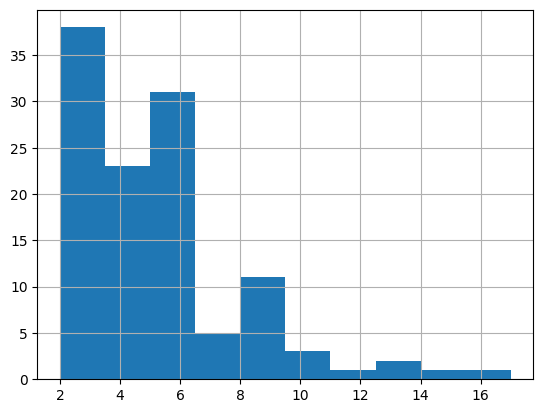

In [15]:
steps = df.groupby('client_id')['step'].agg('max')
        
steps.hist(bins=10)

Из полученной гистограммы видим, что в целом карта пользовательских потоков будет доступной для восприятия: глубина не превышает 17 шагов, но поведение большей части пользователей описывается не более чем 6 шагами

Определяем номера в очереди всем событиям: сначала смотрим на шаг, потом на определенное наименование событий в шаге и определяем последовательные номера каждому отдельному событию в наименовании событий. В результате мы получаем списки sources, их уникальных индексов и словарь соответствий sources и индексов

In [16]:
def get_source_index(df):

    """Функция генерации индексов source

    Args:
        df (pd.DataFrame): исходная таблица с признаками step, source, target.
    Returns:
        dict: словарь с индексами, именами и соответсвиями индексов именам source.
    """

    res_dict = {}

    count = 0
    # получаем индексы источников
    for no, step in enumerate(df['step'].unique().tolist()):
        # получаем уникальные наименования для шага
        res_dict[no+1] = {}
        res_dict[no+1]['sources'] = df[df['step'] == step]['source'].unique().tolist()
        res_dict[no+1]['sources_index'] = []
        for i in range(len(res_dict[no+1]['sources'])):
            res_dict[no+1]['sources_index'].append(count)
            count += 1

    # соединим списки
    for key in res_dict:
        res_dict[key]['sources_dict'] = {}
        for name, no in zip(res_dict[key]['sources'], res_dict[key]['sources_index']):
            res_dict[key]['sources_dict'][name] = no
    return res_dict

In [17]:
source_indexes = get_source_index(df)

Каждому наименованию события ставим в соответствие свой цвет (функция задает либо рандомные, либо кастомные цвета)

In [18]:
def colors_for_sources(df, mode):

    """Генерация цветов rgba

    Returns:
        dict: словарь с цветами, соответствующими каждому индексу
    """
    # словарь, в который сложим цвета в соответствии с индексом
    colors_dict = {}
    
    if mode == 'random':
        # генерим случайные цвета
        for label in df_comp['source'].unique():
            r, g, b = np.random.randint(255, size=3)            
            colors_dict[label] = f'rgba({r}, {g}, {b}, 1)'
            
    elif mode == 'custom':
        # присваиваем ранее подготовленные цвета
        colors = requests.get('https://raw.githubusercontent.com/ElenaNKn/data_projects_ru/refs/heads/master/project_sankey/colors_senkey.json').json()
        for no, label in enumerate(df['source'].unique()):
            colors_dict[label] = colors['custom_colors'][no]
            
    return colors_dict

In [19]:
colors_dict = colors_for_sources(df, 'custom')
colors_dict

{'view_info': 'rgba(255, 165, 0, 1)',
 'product_added_to_cart': 'rgba(81, 170, 86, 1)',
 'checkout_started': 'rgba(29, 160, 189, 1)',
 'checkout_completed': 'rgba(29, 48, 243, 1)',
 'product_removed_from_cart': 'rgba(238, 130, 238, 1)',
 'view_track': 'rgba(230, 57, 70, 1)',
 'view_return': 'rgba(255, 0, 0, 1)',
 'view_financ_discount': 'rgba(255, 217, 2, 1)'}

In [20]:
# пересчитаем количестов юзеров в процентах от входа
def percent_users(sources, targets, values):

    """
    Расчет уникальных id в процентах (для вывода в hover text каждого узла)

    Args:
        sources (list): список с индексами source.
        targets (list): список с индексами target.
        values (list): список с "объемами" потоков.

    Returns:
        list: список с "объемами" потоков в процентах
    """

    # объединим источники и метки и найдем пары
    zip_lists = list(zip(sources, targets, values))

    new_list = []

    # подготовим список словарь с общим объемом трафика в узлах
    unique_dict = {}

    # проходим по каждому узлу
    for source, target, value in zip_lists:
        if source not in unique_dict:
            # находим все источники и считаем общий трафик
            unique_dict[source] = 0
            for sr, tg, vl in zip_lists:
                if sr == source:
                    unique_dict[source] += vl

    # считаем проценты
    for source, target, value in zip_lists:
        new_list.append(round(100 * value / unique_dict[source], 1))

    return new_list

In [21]:
def lists_for_plot(df_comp, source_indexes, colors=colors_dict, frac=0):

    """
    Создаем необходимые для отрисовки диаграммы переменные списков

    Args:
        source_indexes (dict): словарь с именами и индексами source.
        colors (dict): словарь с цветами source.
        frac (int): ограничение на минимальный "объем" между узлами.

    Returns:
        dict: словарь со списками, необходимыми для диаграммы.
    """

    sources = []
    targets = []
    values = []
    labels = []
    link_color = []
    link_text = []

    # проходим по каждому шагу
    for step in tqdm(sorted(df_comp['step'].unique()), desc='Шаг'):
        if step + 1 not in source_indexes:
            continue

        # получаем индекс источника
        temp_dict_source = source_indexes[step]['sources_dict']

        # получаем индексы цели
        temp_dict_target = source_indexes[step+1]['sources_dict']

        # проходим по каждой возможной паре, считаем количество таких пар
        for source, index_source in tqdm(temp_dict_source.items()):
            for target, index_target in temp_dict_target.items():
                # делаем срез данных и считаем количество id
                temp_df = df_comp[(df_comp['step'] == step)&(df_comp['source'] == source)&(df_comp['target'] == target)]
                value = len(temp_df)
                # проверяем минимальный объем потока и добавляем нужные данные
                if value > frac:
                    sources.append(index_source)
                    targets.append(index_target)
                    values.append(value)
                    # делаем поток прозрачным для лучшего отображения
                    link_color.append(colors[source].replace(', 1)', ', 0.2)'))

    labels = []
    colors_labels = []
    for key in source_indexes:
        for name in source_indexes[key]['sources']:
            labels.append(name)
            colors_labels.append(colors[name])

    # посчитаем проценты всех потоков
    perc_values = percent_users(sources, targets, values)

    # добавим значения процентов для howertext
    link_text = []
    for perc in perc_values:
        link_text.append(f"{perc}%")

    # возвратим словарь с вложенными списками
    return {'sources': sources,
            'targets': targets,
            'values': values,
            'labels': labels,
            'colors_labels': colors_labels,
            'link_color': link_color,
            'link_text': link_text}

In [22]:
data_for_plot = lists_for_plot(df, source_indexes)

100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 263.31it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 242.85it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 447.34it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 383.99it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 319.87it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 298.97it/s]

100%|███████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 992.30it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<?, ?it/s]

100%|███████████████████████████

In [23]:
def plot_senkey_diagram(data_dict):

    """
    Функция для генерации объекта диаграммы Сенкей

    Args:
        data_dict (dict): словарь со списками данных для построения.

    Returns:
        plotly.graph_objs._figure.Figure: объект изображения.
    """

    fig = go.Figure(data=[go.Sankey(
        domain = dict(
          x =  [0,1],
          y =  [0,1]
        ),
        orientation = "h",
        valueformat = ".0f",
        node = dict(
          pad = 50,
          thickness = 15,
          line = dict(color = "black", width = 0.1),
          label = data_dict['labels'],
          color = data_dict['colors_labels']
        ),
        link = dict(
          source = data_dict['sources'], # indices correspond to labels, eg A1, A2, A1, B1, ...
          target = data_dict['targets'],
          value = data_dict['values'],
          label = data_dict['link_text'],
          color = data_dict['link_color']
      ))])
    fig.update_layout(title_text="User Flow: Returned Product Users", font_size=10, width=3000, height=1200)

    # возвращаем объект диаграммы
    return fig

Строим sankey-диаграмму, отражающую карту пользовательских потоков для пользователей, вернувших товар

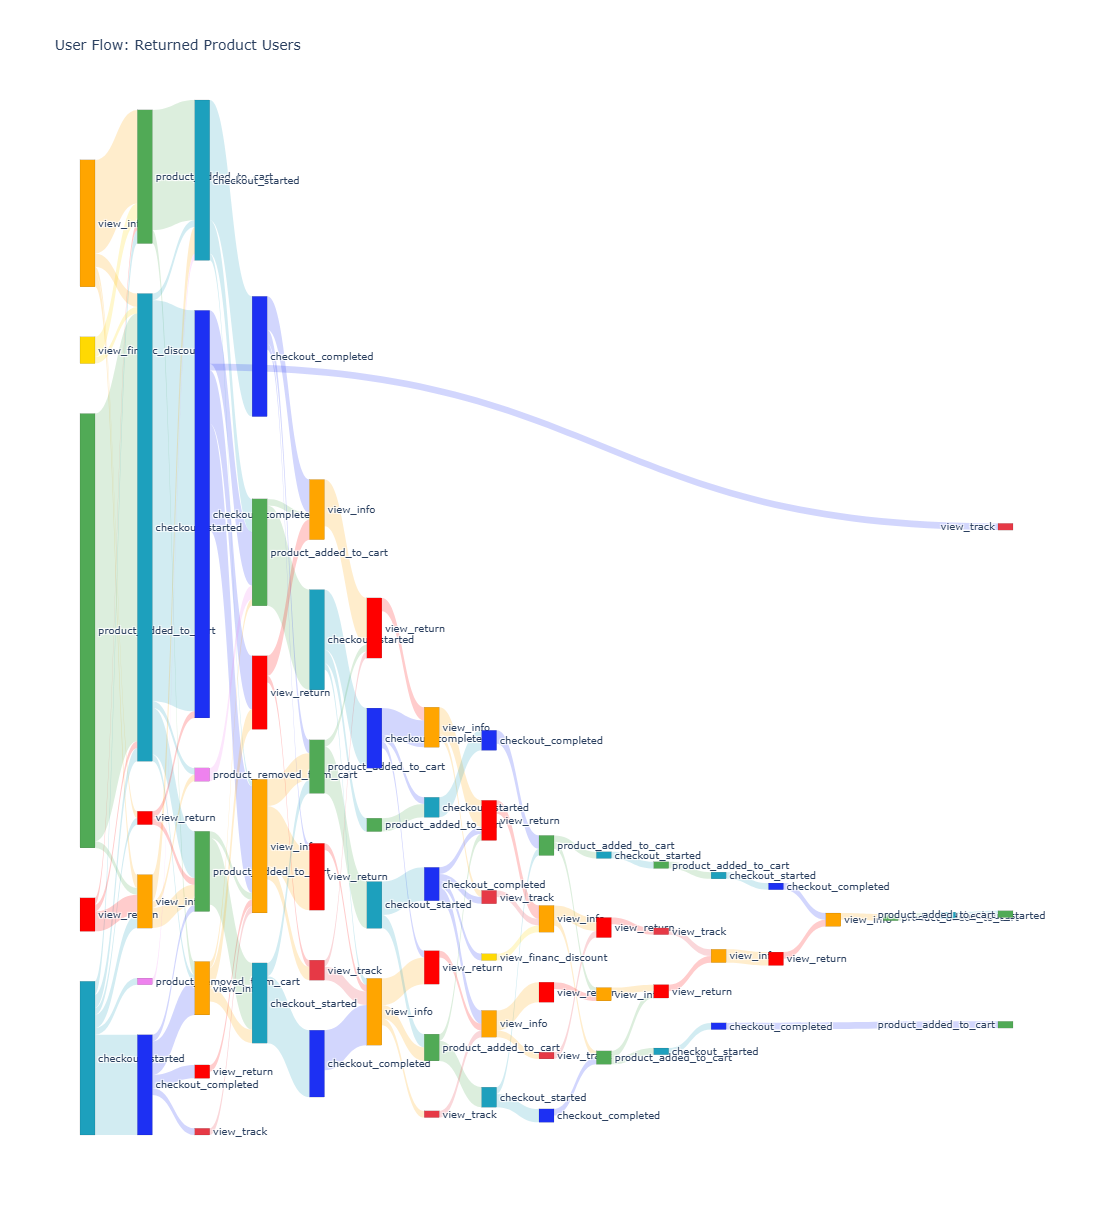

In [24]:
senkey_diagram = plot_senkey_diagram(data_for_plot)
senkey_diagram.show()

Создание html-файла с sankey-диаграммой

In [25]:
senkey_diagram.write_html('UserFlow_returned_product.html', auto_open=True)

Из полученной карты видно следующее:
1. данные, приведенные в датасете не полные (путь некоторых пользователей начинается не с добавления товара в корзину, а сразу с оплаты)
2. есть пользователи, которые уже на старте своего пути смотрели условия возврата товара
3. большая часть остальных возвратов была сделана после просмотра информационных материалов на сайте

Исследуем пункты 2 и 3 подробнее.

In [26]:
# количество клиентов, вернувших товар
clients_with_return = df.client_id.nunique()
clients_with_return

116

In [27]:
# количество и доля пользователей, путь которых был начат с просмотра страницы возврата
cust_initial_return_count = df[(df.step == 1) & (df.event_name == 'view_return')].client_id.nunique()
cust_initial_return_share = round(100 * cust_initial_return_count / df.client_id.nunique(), 2)

print(f'Пользователи, путь которых был начат с просмотра страницы возврата')
print(f'Количество пользователей: {cust_initial_return_count}')
print(f'Доля от вернувших пользователей: {cust_initial_return_share}%')

Пользователи, путь которых был начат с просмотра страницы возврата
Количество пользователей: 5
Доля от вернувших пользователей: 4.31%


Таким образом, возврат от пользователей, которые изначально сомневались, стоит ли покупать товар - это не массовая история. Однако имеет смысл отслеживать таких пользователей (которые заходили на страницу с условиями возврата до того, как добавить продукт в корзину) и добавить им:
- дополнительную модалку, уточняющую их готовность приобрести заказ;
- персонализированную коммуникацию после посупления заказа, направленную на удержание от возврата

Определим, какая доля пользователей смотрела информационные материалы на сайте после того, как сделала заказ, но до того, как перешла на страницы, связанные с возвратом товаров

In [28]:
def check_sequence_efficient(group):
    """
    Функция для проверки наличия последовательности событий checkout_completed -> view_info -> view_return

    Args:
        group: логи одного пользователя.

    Returns:
        bool: True , если пользвоатель заходил на информационные страницы до того, как посетил страницу возврата.
    """
    checkout_times = group[group['event_name'] == 'checkout_completed']['event_timestamp'].values
    view_info_times = group[group['event_name'] == 'view_info']['event_timestamp'].values
    view_return_times = group[group['event_name'] == 'view_return']['event_timestamp'].values
    
    for checkout_time in checkout_times:
        valid_view_info = view_info_times[view_info_times > checkout_time]
        for view_info_time in valid_view_info:
            if any(view_return_time > view_info_time for view_return_time in view_return_times):
                return True
    return False

In [29]:
# количество и доля пользователей, которые заходили на информационные страницы после того, как сделали заказ
# и до того, как начали процедуру возврата товара

cust_info_return_count = df.groupby('client_id').filter(check_sequence_efficient)['client_id'].nunique()
cust_info_return_share = round(100 * cust_info_return_count / df.client_id.nunique(), 2)

print(f'Пользователи, заходившие на информационные страницы после заказа и до заявки на возврат')
print(f'Количество пользователей: {cust_info_return_count}')
print(f'Доля от вернувших пользователей: {cust_info_return_share}%')

Пользователи, заходившие на информационные страницы после заказа и до заявки на возврат
Количество пользователей: 30
Доля от вернувших пользователей: 25.86%


Таким образом, четверть пользователей, вернувших товар, ознакомились до этого с информационными материалами на сайте

Исследуем подробнее, какие страницы они читали до того, как перейти к возврату. Для этого обратимся к необработанному датафрейму df_init и у найденых клиентов выделим все события `'view_info'`, которые находятся между `'checkout_completed'` и `'view_return'`

In [30]:
target_clients = df_init.groupby('client_id').filter(check_sequence_efficient)['client_id'].unique()

result = []

# пробегаемся циклом по требуемым пользователям, выгружаем время heckout_completed и view_return
# берем события view_info, сохраняем если они попадают между heckout_completed и view_return
for client_id in target_clients:
    client_df = df_init[df_init['client_id'] == client_id].sort_values('event_timestamp')
    
    checkout_ts_list = client_df[client_df['event_name'] == 'checkout_completed']['event_timestamp'].tolist()
    return_ts_list = client_df[client_df['event_name'] == 'view_return']['event_timestamp'].tolist()
    
    view_info_df = client_df[client_df['event_name'] == 'view_info']
    
    for idx, row in view_info_df.iterrows():
        view_ts = row['event_timestamp']
        has_before = any(ts < view_ts for ts in checkout_ts_list)
        has_after = any(ts > view_ts for ts in return_ts_list)
        if has_before and has_after:
            result.append(row)

info_df = pd.DataFrame(result)

In [31]:
info_df.head()

,client_id,event_name,event_timestamp,event_data
3193,1741313717-XoA7tCkAvrQ-,view_info,2025-03-08 22:14:26.357,/pages/puffy-mattress-reviews
820,1741313717-XoA7tCkAvrQ-,view_info,2025-03-08 22:14:36.418,/pages/puffy-lux-mattress-reviews
3263,1741313717-XoA7tCkAvrQ-,view_info,2025-03-26 17:25:49.668,/pages/puffy-mattress-reviews
28,1741313717-XoA7tCkAvrQ-,view_info,2025-03-26 17:30:17.241,/pages/puffy-mattress-reviews
3295,1741724699-Fk1TvqbjmPmc,view_info,2025-03-20 14:43:17.700,/pages/contact-puffy-mattress


In [32]:
result_info_views = info_df.groupby('event_data').agg(
    clients = ('client_id', 'nunique'),
    times = ('event_name', 'count')
).sort_values(by = 'clients', ascending = False).head(10)

result_info_views['times_per_client'] = round(result_info_views['times'] / result_info_views['clients'], 2)
result_info_views

,clients,times,times_per_client
event_data,,,
/pages/contact-puffy-mattress,23,45,1.96
/pages/puffy-mattress-sleep-trial,8,15,1.88
/pages/puffy-mattress-reviews,4,7,1.75
/pages/breaking-in-your-new-puffy,3,4,1.33
/blogs/best-sleep/king-vs-queen-bed-detailed-mattress-size-comparison,2,2,1.00
/pages/share,2,3,1.50
/pages/unboxing-your-puffy-mattress,2,2,1.00
/pages/store-locator,2,2,1.00
/pages/puffy-donations,2,7,3.50


In [34]:
# пользователи, вернувшие товар, которые до этого просматривали условия гарантии и отзывы
clients_warenty_reviews = info_df[info_df.event_data.isin(['/pages/puffy-mattress-sleep-trial', 
                                 '/pages/puffy-mattress-reviews'])].client_id.nunique()
clients_warenty_reviews_share = round(100 * clients_warenty_reviews / df.client_id.nunique(), 2)

print(f'Пользователи, которые просматривали условия гарантии и отзывы после заказа товара\n'+
      f'но до перхода на страницы возврата товара\n')
print(f'Количество пользователей: {clients_warenty_reviews}')
print(f'Доля пользователей (от всех пользователей, вернувших товар): {clients_warenty_reviews_share}%')

Пользователи, которые просматривали условия гарантии и отзывы после заказа товара
но до перхода на страницы возврата товара

Количество пользователей: 11
Доля пользователей (от всех пользователей, вернувших товар): 9.48%


Из полученных результатов видим, что 30 клиентов, вернувших товар (25,9% от всех вернувших) просматривали информационные материалы на сайте после размещения заказа, но до перехода на страницы возврата. Из них:

- 23 клиента (19.8% от всех вернувших) смотрели контактную информацию (для более детальной проверки данной ветки требуется информация от отдела по работе с обращениям клиентов);
- 8 клиентов (7.9% от всех вернувших) интересовались гарантией и опцией по trial-периоду матраса;
- 4 клиента (3.4% от всех вернувших) смотрели отзывы на матрасы.

Таким образом, в целом нет конкретной информации о причинах, по которым 116 клиентов вернули заказанный товар. Однако можно предположить, что 11 пользователей, которые после заказа товара интересовались условиями гарантии и отзывами (9,48% от всех вернувших товар), были не в полной мере довольны сделанной покупкой. При этом только 3 клиента ознакомились с сожерданием страницы /pages/breaking-in-your-new-puffy, где описывается вопрос адаптации матраса под человека (который, согласно информации, приведенной на сайте занимает около 30 дней).

**Выводы:**

Анализ карты пользовательских потоков позволил установить следующее:
1. 4,31% пользователей, заказавших товар и впоследствие вернувших его, смотрели страницу возврата товара до заказа товара. Предлагается отслеживать таких пользователей (которые заходили на страницу с условиями возврата до того, как добавить продукт в корзину) и добавить им дополнительную модалку, уточняющую их готовность приобрести заказ, либо ввести персонализированную коммуникацию после поступления заказа, направленную на удержание от возврата;
2. 25,86% пользователей, вернувших товар, в промежутке от заказа до возврата смотрели информационные материалы на сайте. Более детальный анализ просмотренных материалов показал, что в первую очередь они смотрели страницу с контактами магазина (для более детальной проверки данного направления требуется информация от отдела по работе с обращениям клиентов).
3. 9,48% пользователей, вернувших товар интересовались гарантией, опцией по trial-периоду и отзывами на матриасы. Можно предположить, что они были не в полной мере довольны сделанной покупкой. Однако лишь 3 клиента (2.6% от вернувших) заходили на страницу с информационными материалами, описывающими особенности эксплуатации товала в начальный период (о том, что товар - матриас - требует как минимум 30-дневной адаптации под человека)

Таким образом, видна необходимость пересмотра наполнения информационных материалов на сайте и более эффективной коммуникации с пользователями. Следует более концентрированно и наглядно доносить пользователю информацию о необходимости адаптации матраса под клиента. Пока что из данных видно, что пользователи возвращают товар, не прочитав этот материал